# Notebook 2: Synthetic Bearing-2 Generation

**Research**: Bearing RUL Prediction under Shaft Misalignment with Explainable AI
**Strategy**: Augment raw Bearing-1 signal → re-extract features → assign perturbed TCP → save as Bearing-2
**Design intent**: Low signal perturbation to keep model performance high; research focus is XAI, not model complexity.

---

## 1. Global Configuration

In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Path Configuration ──────────────────────────────────────────────────────
ROOT_DIR         = r"/home/praktikan/projects/github/DwiAnggara/ProyekRisetBearing/bearing_1"
BEARING1_NAME    = "bearing_1"
BEARING2_NAME    = "bearing_2"
INPUT_RAW        = os.path.join(ROOT_DIR, f"{BEARING1_NAME}_full.parquet")
INPUT_PROCESSED1 = os.path.join(ROOT_DIR, BEARING1_NAME, "processed_bearing1.parquet")
OUTPUT_PARQUET   = os.path.join(ROOT_DIR, BEARING2_NAME, "processed_bearing2_synthetic_20db_085.parquet")

# ── Signal Parameters (must match Notebook 1) ────────────────────────────────
SAMPLING_RATE   = 2560
SEGMENT_SECONDS = 60
SAMPLES_PER_SEG = SAMPLING_RATE * SEGMENT_SECONDS
TOTAL_DURATION_H = 108
N_SEGMENTS      = TOTAL_DURATION_H * 60
RPM             = 3000
FR              = RPM / 60

# ── Bearing Geometry (UCP 204) ───────────────────────────────────────────────
D_PITCH   = 33.5
D_BALL    = 7.94
Z_BALLS   = 8
ALPHA_DEG = 0
ALPHA_RAD = np.deg2rad(ALPHA_DEG)
DEFECT_BW = 5.0

# ── Augmentation Parameters ──────────────────────────────────────────────────
# Keep SNR high (close to original) so feature distributions stay similar.
# Phase-differentiated noise prevents identical BHI trajectories between bearings.
SNR_HEALTHY_DB  = 20      # dB — healthy phase (higher SNR = cleaner signal = subtle aug)
SNR_DEGRADE_DB  = 15     # dB — degradation phase (slightly more noise)
SCALE_HEALTHY   = (0.85, 1.15)   # amplitude scale range — healthy
SCALE_DEGRADE   = (0.65, 1.35)   # amplitude scale range — degradation

# ── TCP Perturbation ─────────────────────────────────────────────────────────
TCP_PERTURB_RANGE = (-50, 50)    # ± minutes from Bearing-1 TCP
TCP_MIN_GUARD     = 100          # earliest allowed TCP (min)

# ── CUSUM & EMA (same as Notebook 1) ────────────────────────────────────────
TARGET_TCP_AXIS     = 'y'
CUSUM_K             = 1.0
CUSUM_H             = 8.0
CUSUM_BASELINE_FRAC = 0.50
EMA_SPAN            = 20

DEGRADATION_TYPE = 'linear'

AXES = ['x', 'y', 'z']

# ── Plot Style ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 1.4,
    'legend.fontsize': 9,
})

print(f"Input raw parquet      : {INPUT_RAW}")
print(f"Input processed B1     : {INPUT_PROCESSED1}")
print(f"Output path            : {OUTPUT_PARQUET}")
print(f"Samples per segment    : {SAMPLES_PER_SEG:,}")
print(f"Total segments         : {N_SEGMENTS:,}")

Input raw parquet      : D:\ProyekDosen\Riset Bearing ShaftMissalignment + XAI\bearing_1_full.parquet
Input processed B1     : D:\ProyekDosen\Riset Bearing ShaftMissalignment + XAI\bearing_1\processed_bearing1.parquet
Output path            : D:\ProyekDosen\Riset Bearing ShaftMissalignment + XAI\bearing_2\processed_bearing2_synthetic_100db.parquet
Samples per segment    : 153,600
Total segments         : 6,480


---

## 2. Bearing Defect Frequencies

In [ ]:
def compute_defect_frequencies(fr, D, d, Z, alpha):
    """Compute BPFO, BPFI, FTF, and BSF using standard bearing kinematic equations."""
    ratio = (d / D) * np.cos(alpha)
    
    # Calculation of 4 Basic Frequencies
    BPFO = (Z / 2) * fr * (1 - ratio)             # Outer ring defect frequency
    BPFI = (Z / 2) * fr * (1 + ratio)             # Inner ring defect frequency
    FTF  = 0.5 * fr * (1 - ratio)                 # Cage/Fundamental Train frequency
    BSF  = (D / (2 * d)) * fr * (1 - ratio ** 2)  # Ball spin frequency
    
    return BPFO, BPFI, FTF, BSF

BPFO, BPFI, FTF, BSF = compute_defect_frequencies(FR, D_PITCH, D_BALL, Z_BALLS, ALPHA_RAD)

print(f"BPFO (Outer) : {BPFO:.2f} Hz")
print(f"BPFI (Inner) : {BPFI:.2f} Hz")
print(f"FTF  (Cage)  : {FTF:.2f} Hz")
print(f"BSF  (Ball)  : {BSF:.2f} Hz")

BPFO : 152.60 Hz
BPFI : 247.40 Hz
BSF  : 99.55 Hz


---

## 3. Load Reference TCP from Bearing-1

In [3]:
df_b1 = pd.read_parquet(INPUT_PROCESSED1)
TCP_B1 = int(df_b1['T_cp'].iloc[0]) if 'T_cp' in df_b1.columns else 2381

print(f"Bearing-1 TCP (segment index) : {TCP_B1}  ({TCP_B1} min / {TCP_B1/60:.2f} h)")
print(f"Bearing-1 processed shape     : {df_b1.shape}")

Bearing-1 TCP (segment index) : 2381  (2381 min / 39.68 h)
Bearing-1 processed shape     : (6480, 61)


---

## 4. Load Raw Parquet (Bearing-1 Source Signal)

> **Critical**: augmentation must happen on the raw signal, not on processed features.
> Using `pyarrow.dataset` for memory-efficient batch streaming (identical to Notebook 1).

In [4]:
import pyarrow.dataset as ds

dataset = ds.dataset(INPUT_RAW, format="parquet")
schema_names = dataset.schema.names

col_x = [c for c in schema_names if c.strip().lower() == 'x'][0]
col_y = [c for c in schema_names if c.strip().lower() == 'y'][0]
col_z = [c for c in schema_names if c.strip().lower() == 'z'][0]
target_cols = [col_x, col_y, col_z]

print(f"Raw dataset schema names : {schema_names}")
print(f"Columns mapped           : {target_cols}")

Raw dataset schema names : ['time', 'X', 'Y', 'Z']
Columns mapped           : ['X', 'Y', 'Z']


---

## 5. Augmentation Functions

In [5]:
def add_gaussian_noise(sig, snr_db):
    """Add Gaussian noise to a signal at a specified SNR (dB)."""
    rms_sig = np.sqrt(np.mean(sig ** 2)) + 1e-12
    sigma   = rms_sig / (10 ** (snr_db / 20.0))
    return sig + np.random.normal(0.0, sigma, len(sig))


def augment_segment(sig, seg_idx, tcp_minute):
    """Apply phase-aware Gaussian noise + amplitude scaling to one axis signal."""
    in_degradation = seg_idx >= tcp_minute
    snr_db  = SNR_DEGRADE_DB if in_degradation else SNR_HEALTHY_DB
    lo, hi  = SCALE_DEGRADE  if in_degradation else SCALE_HEALTHY
    scale   = np.random.uniform(lo, hi)
    return add_gaussian_noise(sig, snr_db) * scale

---

## 6. Feature Extraction (Identical to Notebook 1)

In [6]:
def extract_time_domain_features(data):
    """Compute 11 time-domain features for shape (N, S, A) input."""
    mean_val    = np.mean(data, axis=1)
    std_val     = np.std(data, axis=1, ddof=1)
    rms         = np.sqrt(np.mean(data ** 2, axis=1))
    peak        = np.max(np.abs(data), axis=1)
    p2p         = np.max(data, axis=1) - np.min(data, axis=1)
    mean_abs    = np.mean(np.abs(data), axis=1)
    mean_sq_abs = np.mean(np.sqrt(np.abs(data)), axis=1)

    N, S, A  = data.shape
    skewness = np.zeros((N, A), dtype=np.float32)
    kurtosis = np.zeros((N, A), dtype=np.float32)
    for a in range(A):
        skewness[:, a] = stats.skew(data[:, :, a], axis=1)
        kurtosis[:, a] = stats.kurtosis(data[:, :, a], axis=1)

    peak_factor      = peak / (rms + 1e-12)
    clearance_factor = peak / (mean_sq_abs ** 2 + 1e-12)
    shape_factor     = rms / (mean_abs + 1e-12)
    impulse_factor   = peak / (mean_abs + 1e-12)

    return {
        'td_mean'            : mean_val,
        'td_std'             : std_val,
        'td_rms'             : rms,
        'td_peak_value'      : peak,
        'td_p2p'             : p2p,
        'td_skewness'        : skewness,
        'td_kurtosis'        : kurtosis,
        'td_peak_factor'     : peak_factor,
        'td_clearance_factor': clearance_factor,
        'td_shape_factor'    : shape_factor,
        'td_impulse_factor'  : impulse_factor,
    }


def extract_frequency_domain_features(data, fs, d_freqs, bw):
    """Compute FFT-based spectral features and defect band energies."""
    N, S, A  = data.shape
    freqs    = np.fft.rfftfreq(S, d=1.0 / fs)
    fft_amp  = np.abs(np.fft.rfft(data, axis=1)) / S
    amp_sum  = np.sum(fft_amp, axis=1, keepdims=True) + 1e-12
    freq_mat = freqs[np.newaxis, :, np.newaxis]

    mean_freq    = np.sum(freq_mat * fft_amp, axis=1) / amp_sum.squeeze(1)
    fft_p2p      = np.max(fft_amp, axis=1) - np.min(fft_amp, axis=1)
    spectral_eng = np.sum(fft_amp ** 2, axis=1)

    def band_energy(center):
        mask = (freqs >= center - bw) & (freqs <= center + bw)
        return np.sum(fft_amp[:, mask, :] ** 2, axis=1)

    return {
        'fd_mean_freq'      : mean_freq,
        'fd_centroid_freq'  : mean_freq.copy(),
        'fd_fft_p2p'        : fft_p2p,
        'fd_spectral_energy': spectral_eng,
        'fd_bpfo_energy'    : band_energy(d_freqs['BPFO']),
        'fd_bpfi_energy'    : band_energy(d_freqs['BPFI']),
        'fd_bsf_energy'     : band_energy(d_freqs['BSF']),
    }, fft_amp, freqs

---

## 7. Augment + Extract Features (Chunked Streaming)

Loop mirrors Notebook 1 exactly; augmentation is applied per-segment before feature extraction.

In [7]:
td_names = ['td_mean', 'td_std', 'td_rms', 'td_peak_value', 'td_p2p',
            'td_skewness', 'td_kurtosis', 'td_peak_factor',
            'td_clearance_factor', 'td_shape_factor', 'td_impulse_factor']
fd_names = ['fd_mean_freq', 'fd_centroid_freq', 'fd_fft_p2p',
            'fd_spectral_energy', 'fd_bpfo_energy', 'fd_bpfi_energy', 'fd_bsf_energy']

td_list = {k: [] for k in td_names}
fd_list = {k: [] for k in fd_names}

seg_count  = 0
buffer     = np.empty((SAMPLES_PER_SEG, 3), dtype=np.float32)
buffer_idx = 0

for batch in dataset.to_batches(columns=target_cols, batch_size=SAMPLES_PER_SEG):
    if seg_count >= N_SEGMENTS:
        break

    chunk      = batch.to_pandas().values.astype(np.float32)
    chunk_rows = chunk.shape[0]
    pos        = 0

    while pos < chunk_rows and seg_count < N_SEGMENTS:
        take = min(SAMPLES_PER_SEG - buffer_idx, chunk_rows - pos)
        buffer[buffer_idx:buffer_idx + take] = chunk[pos:pos + take]
        buffer_idx += take
        pos        += take

        if buffer_idx == SAMPLES_PER_SEG:
            # Augment each axis independently before feature extraction
            aug_buf = buffer.copy()
            for a in range(3):
                aug_buf[:, a] = augment_segment(aug_buf[:, a], seg_count, TCP_B1)

            seg_data = aug_buf.reshape(1, SAMPLES_PER_SEG, 3)
            td = extract_time_domain_features(seg_data)
            fd, _, _ = extract_frequency_domain_features(seg_data, SAMPLING_RATE, defect_freqs, DEFECT_BW)

            for k in td_names: td_list[k].append(td[k][0])
            for k in fd_names: fd_list[k].append(fd[k][0])

            seg_count  += 1
            buffer_idx  = 0

            if seg_count % 1500 == 0:
                print(f"Processed {seg_count}/{N_SEGMENTS} segments...")

print(f"Augmented feature extraction complete — {seg_count} segments processed.")

# Assemble DataFrame
seg_time   = np.arange(seg_count) * SEGMENT_SECONDS
feat_dict  = {'segment': np.arange(seg_count),
              'time_s': seg_time,
              'time_min': seg_time / 60}

for name, lst in td_list.items():
    arr = np.array(lst)
    for i, ax in enumerate(AXES):
        feat_dict[f"{name}_{ax}"] = arr[:, i].astype(np.float64)

for name, lst in fd_list.items():
    arr = np.array(lst)
    for i, ax in enumerate(AXES):
        feat_dict[f"{name}_{ax}"] = arr[:, i].astype(np.float64)

df_b2 = pd.DataFrame(feat_dict)
print(f"Feature matrix shape: {df_b2.shape}")
df_b2.head(3)

Processed 1500/6480 segments...
Processed 3000/6480 segments...
Processed 4500/6480 segments...
Processed 6000/6480 segments...
Augmented feature extraction complete — 6480 segments processed.
Feature matrix shape: (6480, 57)


,segment,time_s,time_min,td_mean_x,td_mean_y,td_mean_z,td_std_x,td_std_y,td_std_z,td_rms_x,...,fd_spectral_energy_z,fd_bpfo_energy_x,fd_bpfo_energy_y,fd_bpfo_energy_z,fd_bpfi_energy_x,fd_bpfi_energy_y,fd_bpfi_energy_z,fd_bsf_energy_x,fd_bsf_energy_y,fd_bsf_energy_z
0,0,0,0.0,-0.000417,-0.000119,0.000226,9.158787,8.302030,4.518922,9.158752,...,10.210546,2.407244,0.196925,0.026671,0.788811,0.068780,0.004573,1.934073,0.045325,0.075030
1,1,60,1.0,0.000415,0.000132,0.000373,9.270812,8.209215,4.510399,9.270774,...,10.171996,2.122997,0.196029,0.025926,0.717751,0.066607,0.004903,1.899441,0.045187,0.076280
2,2,120,2.0,-0.000276,-0.000189,-0.001094,8.907638,8.242054,4.501083,8.907604,...,10.130104,2.031941,0.184606,0.023567,0.702440,0.064541,0.004398,1.740267,0.043407,0.071521


---

## 8. EMA Smoothing

In [8]:
for ax in AXES:
    df_b2[f"rms_ema_{ax}"] = df_b2[f"td_rms_{ax}"].ewm(span=EMA_SPAN, adjust=False).mean()

print("EMA applied.")

EMA applied.


---

## 9. TCP Assignment — Perturbed from Bearing-1

> Rationale: Gaussian noise + mild amplitude scaling preserves the degradation trend.
> Re-running CUSUM would yield a value very close to TCP_B1. Instead, a bounded
> random perturbation (±50 min) simulates natural bearing-to-bearing variability
> and makes the justification transparent in the paper.

In [9]:
perturb  = np.random.randint(*TCP_PERTURB_RANGE)
TCP_B2   = max(TCP_MIN_GUARD, TCP_B1 + perturb)
T_f_B2   = seg_count - 1

print(f"Bearing-1 TCP     : {TCP_B1} min  ({TCP_B1/60:.2f} h)")
print(f"Perturbation      : {perturb:+d} min")
print(f"Bearing-2 TCP     : {TCP_B2} min  ({TCP_B2/60:.2f} h)")
print(f"Bearing-2 T_f     : {T_f_B2} min  ({T_f_B2/60:.2f} h)")

Bearing-1 TCP     : 2381 min  (39.68 h)
Perturbation      : -45 min
Bearing-2 TCP     : 2336 min  (38.93 h)
Bearing-2 T_f     : 6479 min  (107.98 h)


---

## 10. BHI Labeling

In [10]:
def compute_bhi(n, tcp_idx, degradation_type='linear'):
    """Generate BHI = 1 (healthy) → 0 (failure), degrading after TCP."""
    bhi    = np.ones(n)
    n_deg  = n - tcp_idx
    t_norm = np.linspace(0, 1, n_deg)

    if degradation_type == 'linear':
        bhi[tcp_idx:] = 1 - t_norm
    elif degradation_type == 'sigmoid':
        k = 10
        bhi[tcp_idx:] = 1 - (1 / (1 + np.exp(-k * (t_norm - 0.5))))
        lo, hi = bhi[tcp_idx:].min(), bhi[tcp_idx:].max()
        bhi[tcp_idx:] = 1 - (bhi[tcp_idx:] - lo) / (hi - lo + 1e-12)
    else:
        raise ValueError(f"Unknown degradation_type: {degradation_type}")

    return np.clip(bhi, 0, 1)

bhi_b2 = compute_bhi(seg_count, TCP_B2, DEGRADATION_TYPE)
df_b2['bhi']       = bhi_b2
df_b2['label_vcd'] = (df_b2['segment'] >= TCP_B2).astype(int)
df_b2['T_cp']      = TCP_B2
df_b2['T_f']       = T_f_B2

print(f"BHI type  : {DEGRADATION_TYPE}")
print(f"BHI[0]    : {bhi_b2[0]:.4f}  |  BHI[tcp] : {bhi_b2[TCP_B2]:.4f}  |  BHI[-1] : {bhi_b2[-1]:.4f}")

BHI type  : linear
BHI[0]    : 1.0000  |  BHI[tcp] : 1.0000  |  BHI[-1] : 0.0000


---

## 12. Visualizations

### Plot 1 — BHI Comparison: Bearing-1 vs Bearing-2

In [11]:
meta_cols = ['segment', 'time_s', 'time_min', 'bhi', 'label_vcd', 'T_cp', 'T_f']
ema_cols  = [c for c in df_b2.columns if c.startswith('rms_ema_')]
feat_cols = [c for c in df_b2.columns if c not in meta_cols + ema_cols]

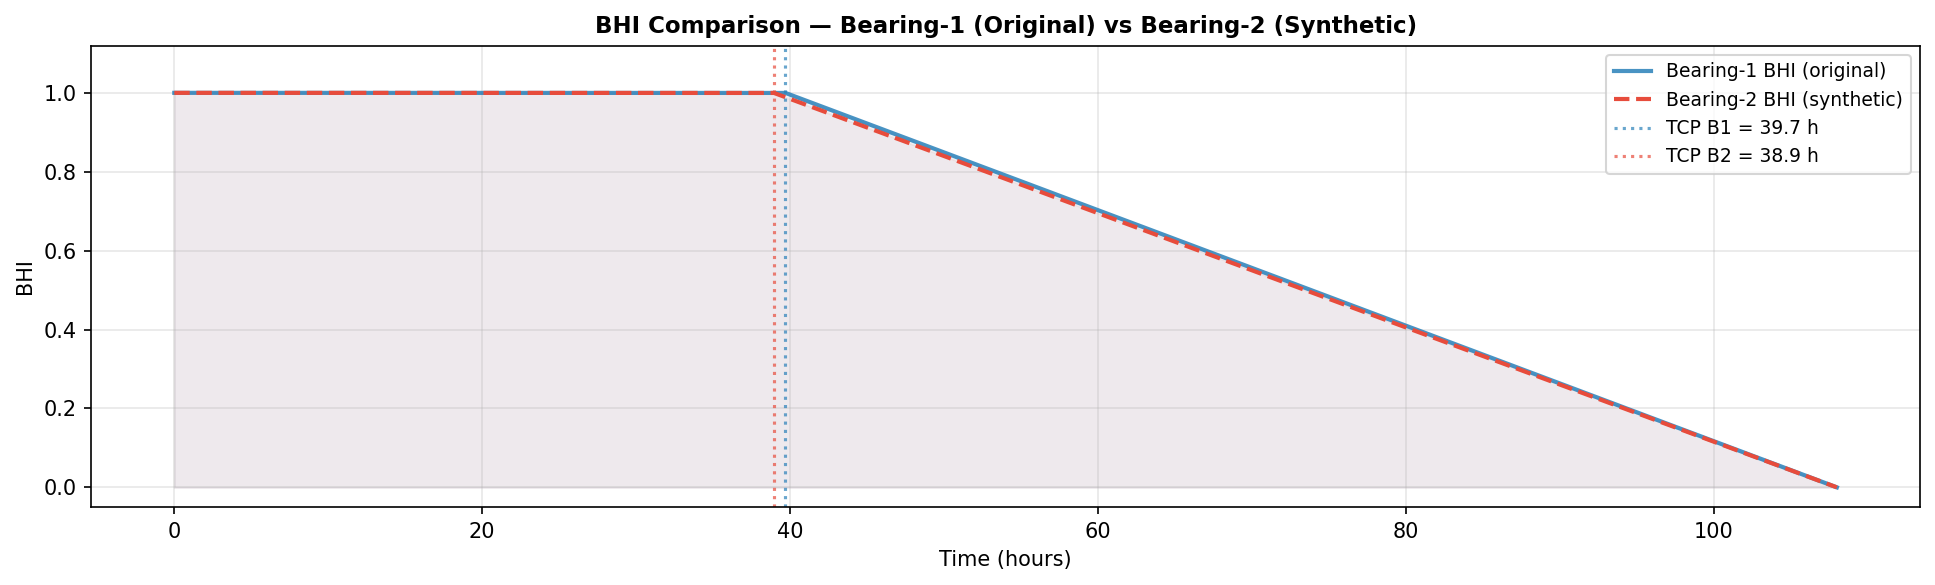

In [12]:
t_axis_b1 = df_b1['time_min'].values / 60
t_axis_b2 = df_b2['time_min'].values / 60

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(t_axis_b1, df_b1['bhi'], color='#2980B9', lw=2.0, label='Bearing-1 BHI (original)', alpha=0.85)
ax.plot(t_axis_b2, bhi_b2, color='#E74C3C', lw=2.0, ls='--', label='Bearing-2 BHI (synthetic)')
ax.axvline(TCP_B1 / 60, color='#2980B9', lw=1.5, ls=':', alpha=0.7, label=f'TCP B1 = {TCP_B1/60:.1f} h')
ax.axvline(TCP_B2 / 60, color='#E74C3C', lw=1.5, ls=':', alpha=0.7, label=f'TCP B2 = {TCP_B2/60:.1f} h')
ax.fill_between(t_axis_b2, 0, bhi_b2, alpha=0.07, color='#E74C3C')
ax.fill_between(t_axis_b1, 0, df_b1['bhi'].values, alpha=0.07, color='#2980B9')
ax.set_ylim(-0.05, 1.12)
ax.set_xlabel('Time (hours)')
ax.set_ylabel('BHI')
ax.set_title('BHI Comparison — Bearing-1 (Original) vs Bearing-2 (Synthetic)', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('plot1_bhi_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

### Plot 2 — RMS Trend Comparison (All Axes)

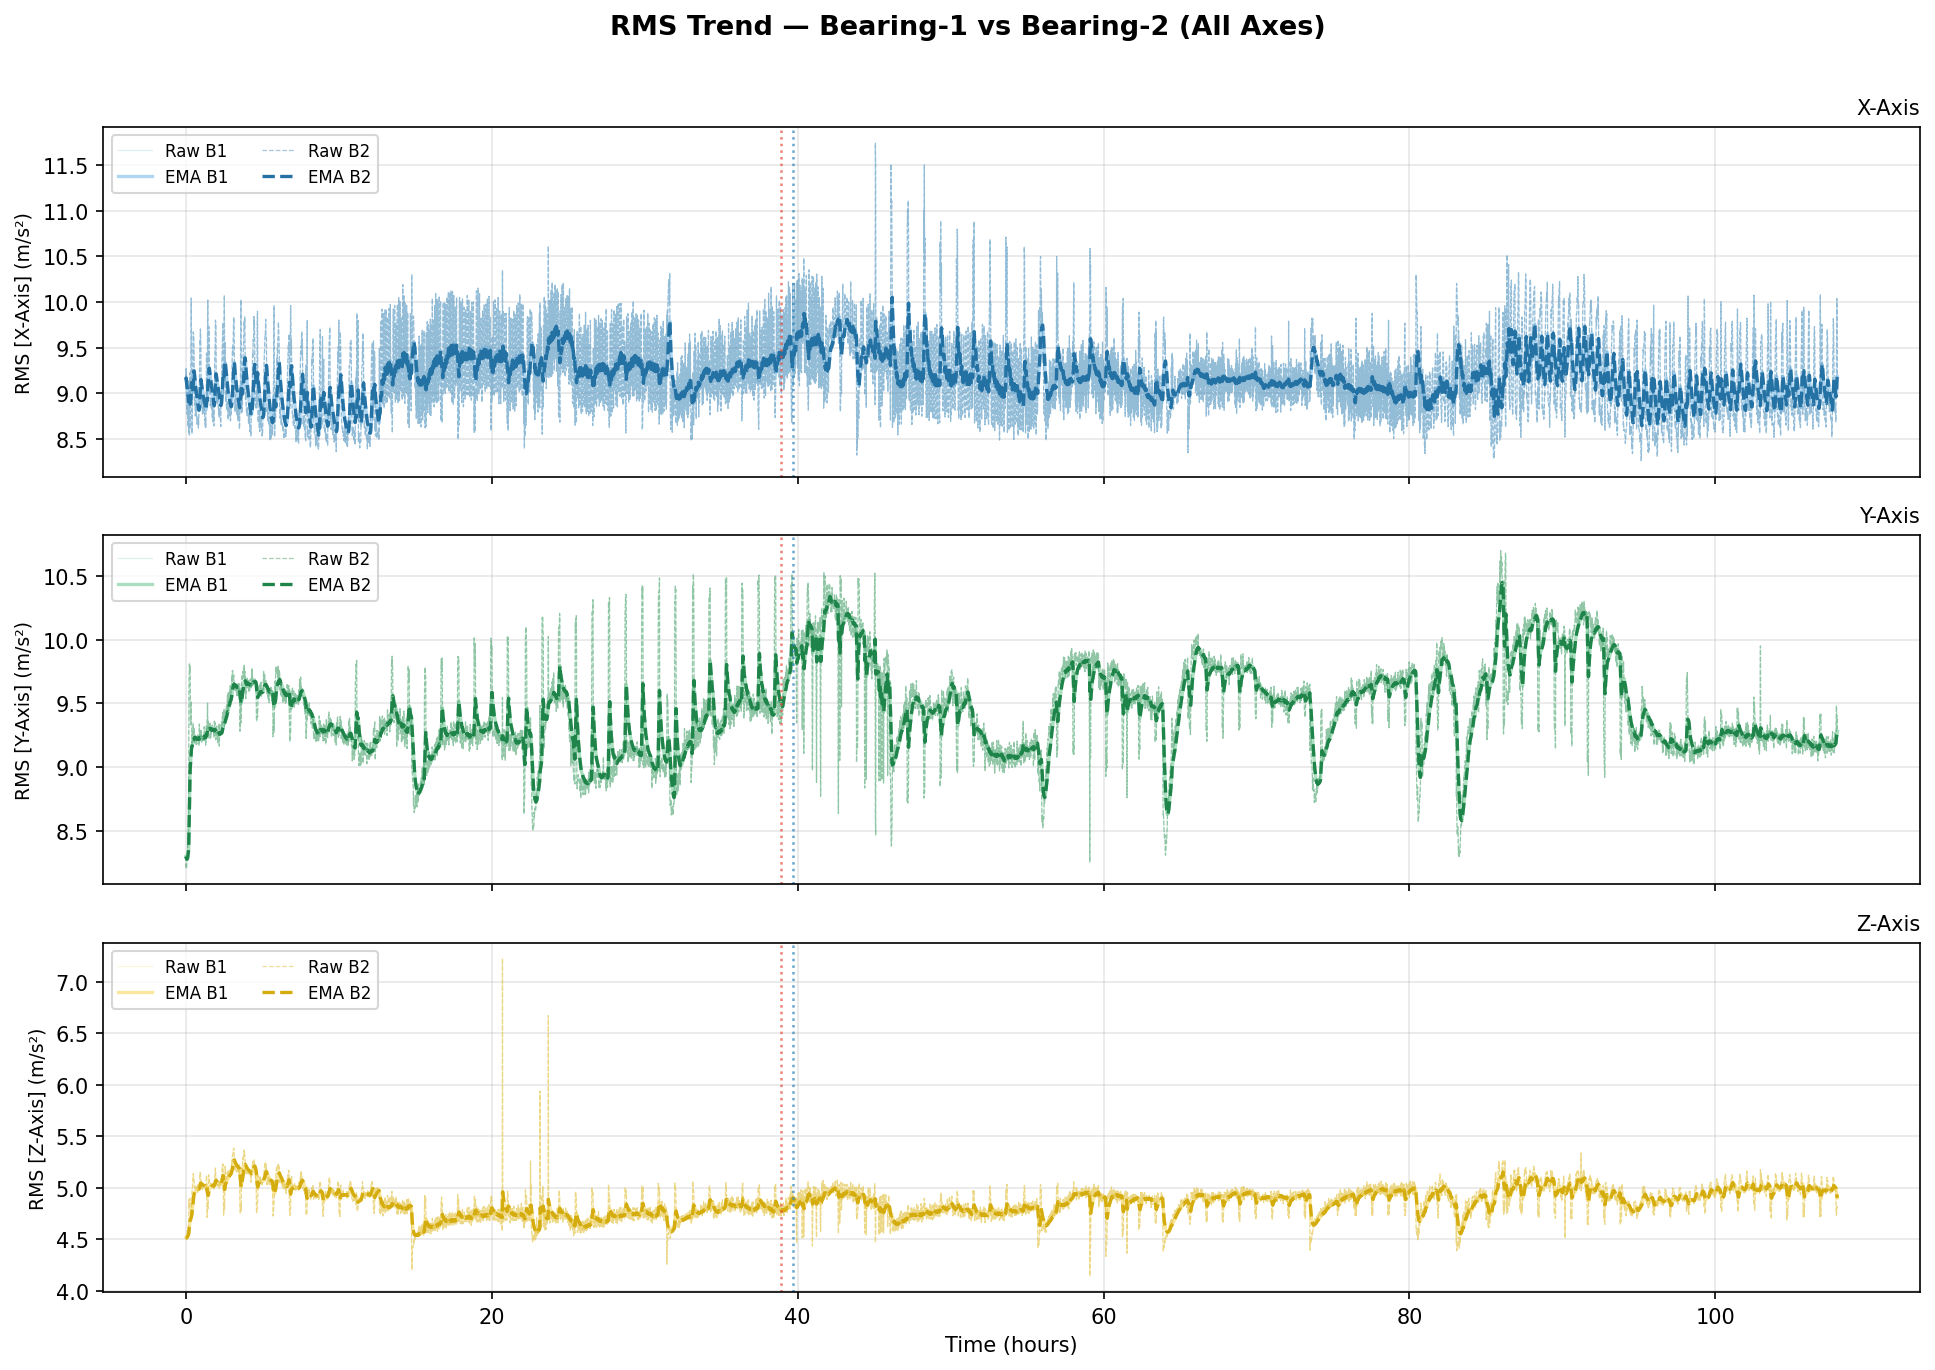

In [13]:
rms_cols = [f"td_rms_{ax}" for ax in AXES]
labels   = ['X-Axis', 'Y-Axis', 'Z-Axis']
colors_b1 = ['#AED6F1', '#A9DFBF', '#F9E79F']
colors_b2 = ['#2471A3', '#1E8449', '#D4AC0D']

fig, axes_plt = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
fig.suptitle('RMS Trend — Bearing-1 vs Bearing-2 (All Axes)', fontweight='bold', fontsize=13, y=1.01)

for i, (col, label) in enumerate(zip(rms_cols, labels)):
    ax = axes_plt[i]
    ema_b1 = df_b1[f"rms_ema_{AXES[i]}"].values if f"rms_ema_{AXES[i]}" in df_b1.columns else df_b1[col].values
    ema_b2 = df_b2[f"rms_ema_{AXES[i]}"].values

    ax.plot(t_axis_b1, df_b1[col].values, color=colors_b1[i], lw=0.6, alpha=0.4, label='Raw B1')
    ax.plot(t_axis_b1, ema_b1,            color=colors_b1[i], lw=1.6, label='EMA B1')
    ax.plot(t_axis_b2, df_b2[col].values, color=colors_b2[i], lw=0.6, alpha=0.4, ls='--', label='Raw B2')
    ax.plot(t_axis_b2, ema_b2,            color=colors_b2[i], lw=1.6, ls='--', label='EMA B2')
    ax.axvline(TCP_B1 / 60, color='#2980B9', lw=1.2, ls=':', alpha=0.7)
    ax.axvline(TCP_B2 / 60, color='#E74C3C', lw=1.2, ls=':', alpha=0.7)
    ax.set_ylabel(f'RMS [{label}] (m/s²)', fontsize=9)
    ax.legend(fontsize=8, loc='upper left', ncol=2)
    ax.set_title(label, fontsize=10, loc='right')

axes_plt[-1].set_xlabel('Time (hours)')
plt.tight_layout()
plt.savefig('plot2_rms_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

### Plot 3 — Feature Distribution Shift: B1 vs B2 (Key Features)

Overlay KDE plots to confirm synthetic data stays within a plausible distribution envelope.

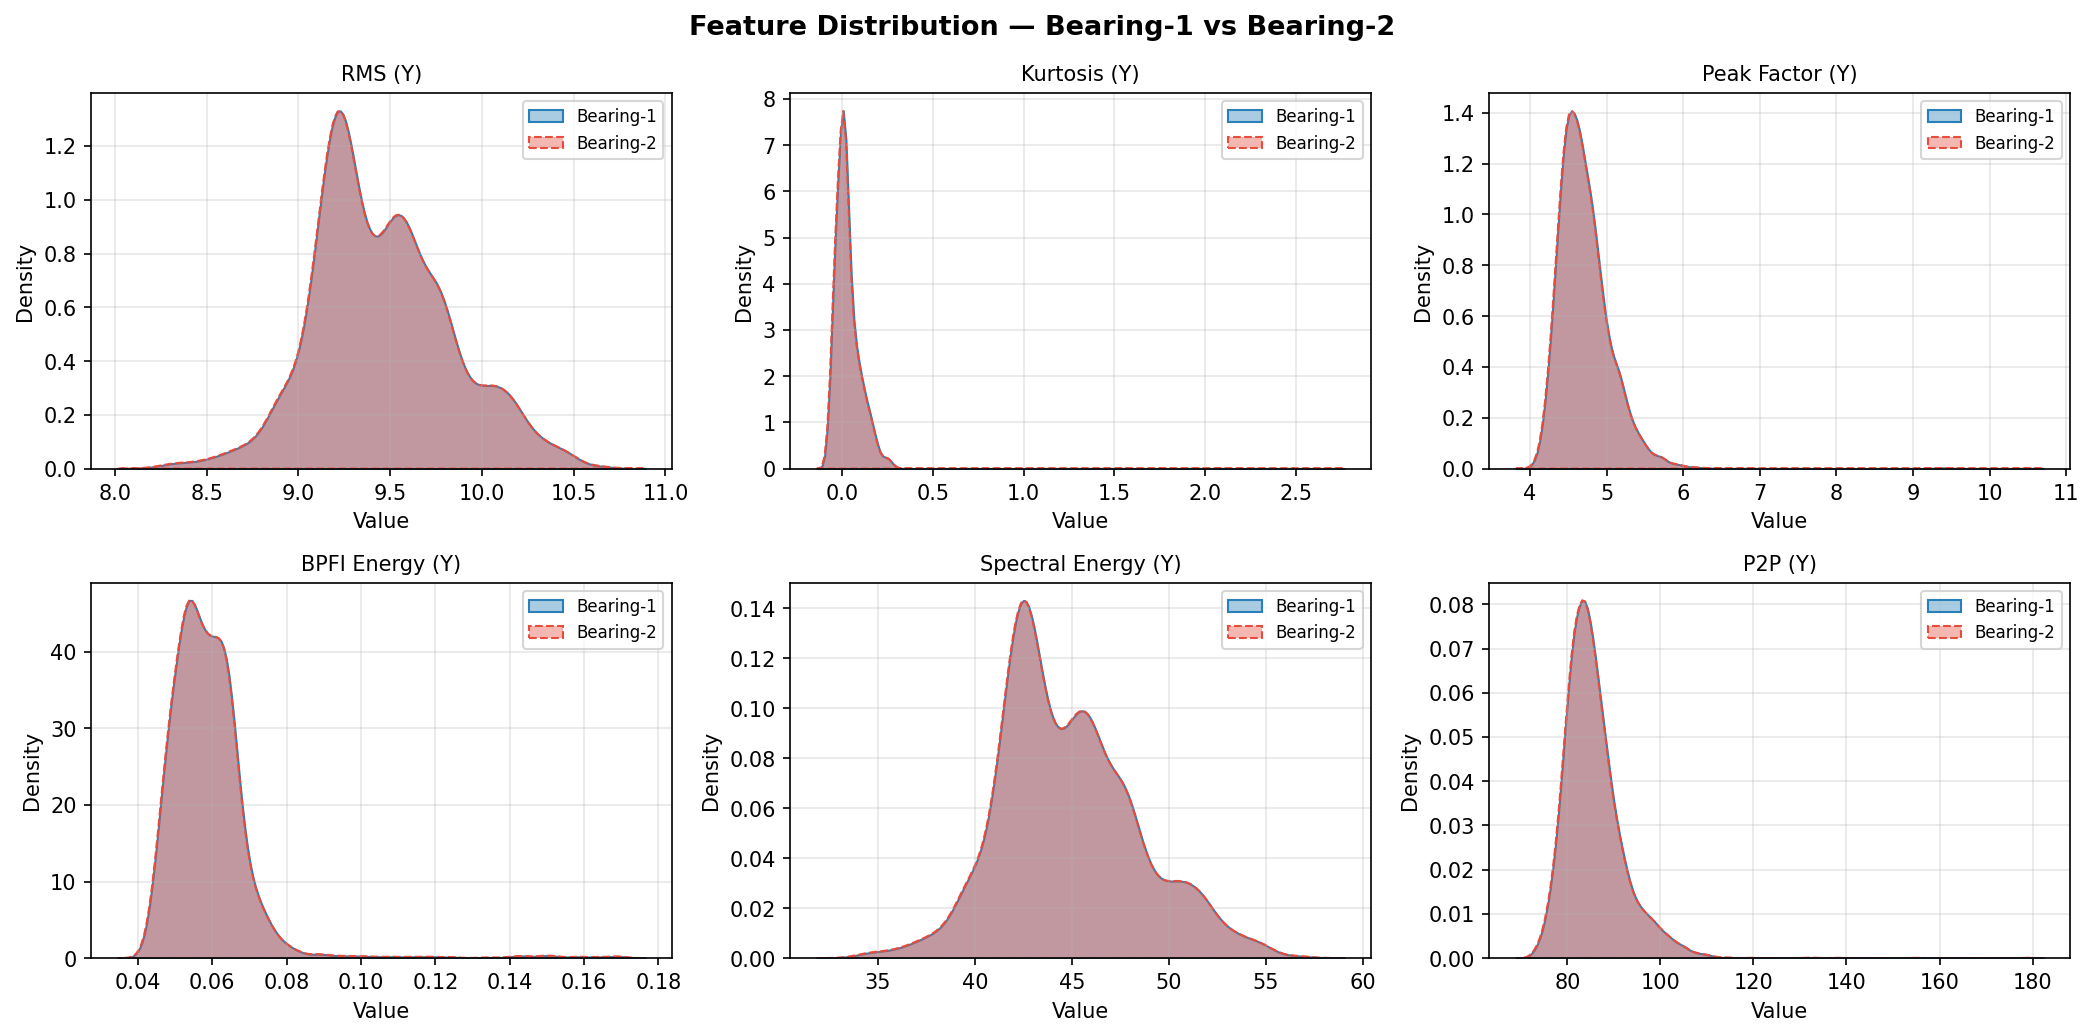

In [14]:
key_features = [
    'td_rms_y', 'td_kurtosis_y', 'td_peak_factor_y',
    'fd_bpfi_energy_y', 'fd_spectral_energy_y', 'td_p2p_y'
]
key_labels = [
    'RMS (Y)', 'Kurtosis (Y)', 'Peak Factor (Y)',
    'BPFI Energy (Y)', 'Spectral Energy (Y)', 'P2P (Y)'
]

fig, axes_dist = plt.subplots(2, 3, figsize=(14, 7))
fig.suptitle('Feature Distribution — Bearing-1 vs Bearing-2', fontweight='bold', fontsize=13)

for ax, feat, lbl in zip(axes_dist.flat, key_features, key_labels):
    b1_vals = df_b1[feat].dropna().values if feat in df_b1.columns else np.array([])
    b2_vals = df_b2[feat].dropna().values if feat in df_b2.columns else np.array([])
    if len(b1_vals):
        sns.kdeplot(b1_vals, ax=ax, fill=True, color='#2980B9', alpha=0.4, label='Bearing-1')
    if len(b2_vals):
        sns.kdeplot(b2_vals, ax=ax, fill=True, color='#E74C3C', alpha=0.4, label='Bearing-2', ls='--')
    ax.set_title(lbl, fontsize=10)
    ax.set_xlabel('Value')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('plot3_feature_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

### Plot 4 — Pearson Correlation: B1 vs B2 (Numerical Sanity Check)

High correlation across all features confirms synthetic data retains the temporal structure of B1.

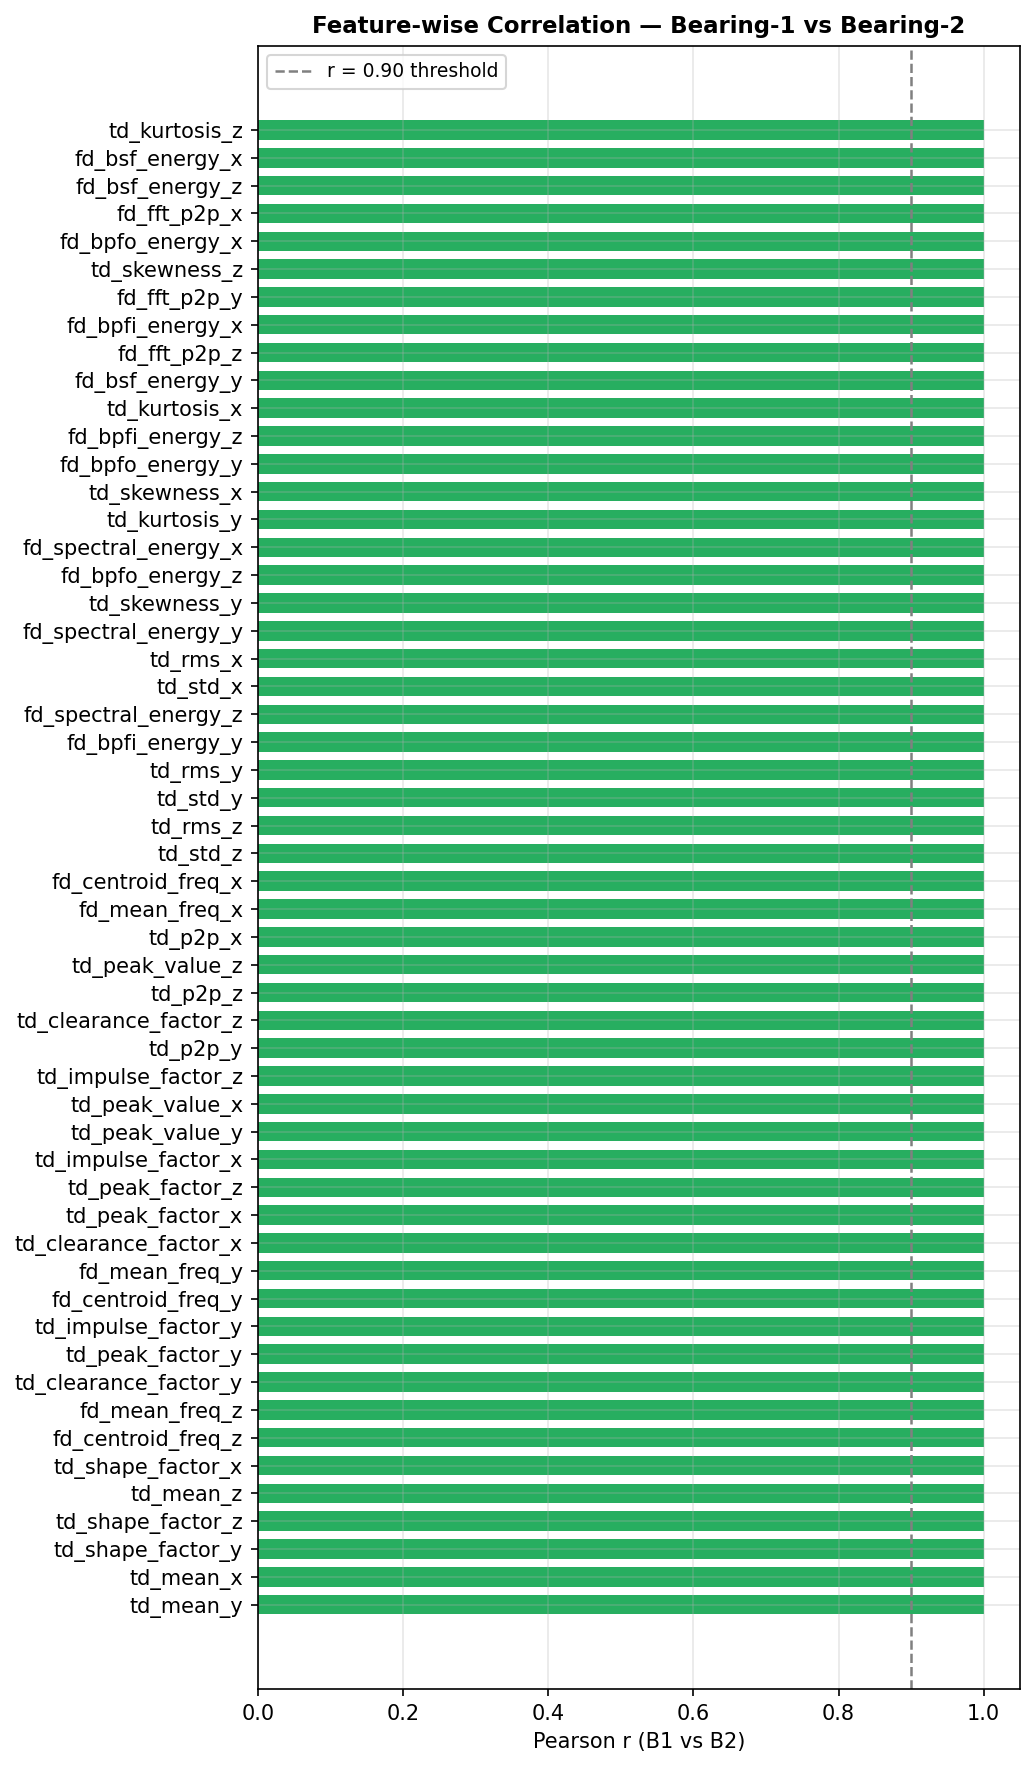


Median feature correlation (B1 vs B2): 1.0000
Features with r < 0.90: 0 / 54


In [15]:
shared_feat = [c for c in feat_cols if c in df_b1.columns and c in df_b2.columns]
corr_vals   = [np.corrcoef(df_b1[f].values, df_b2[f].values)[0, 1] for f in shared_feat]
corr_series = pd.Series(corr_vals, index=shared_feat).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, max(5, len(shared_feat) * 0.22)))
ax.barh(corr_series.index, corr_series.values,
        color=['#E74C3C' if v < 0.90 else '#27AE60' for v in corr_series.values],
        edgecolor='none', height=0.7)
ax.axvline(0.90, color='gray', lw=1.2, ls='--', label='r = 0.90 threshold')
ax.set_xlim(0, 1.05)
ax.set_xlabel('Pearson r (B1 vs B2)')
ax.set_title('Feature-wise Correlation — Bearing-1 vs Bearing-2', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('plot4_feature_correlation.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"\nMedian feature correlation (B1 vs B2): {corr_series.median():.4f}")
print(f"Features with r < 0.90: {(corr_series < 0.90).sum()} / {len(corr_series)}")

### Plot 5 — Augmentation Effect: Segment Sample (Raw vs Augmented Signal)

Visual confirmation that the augmented signal is perceptually similar to the original.

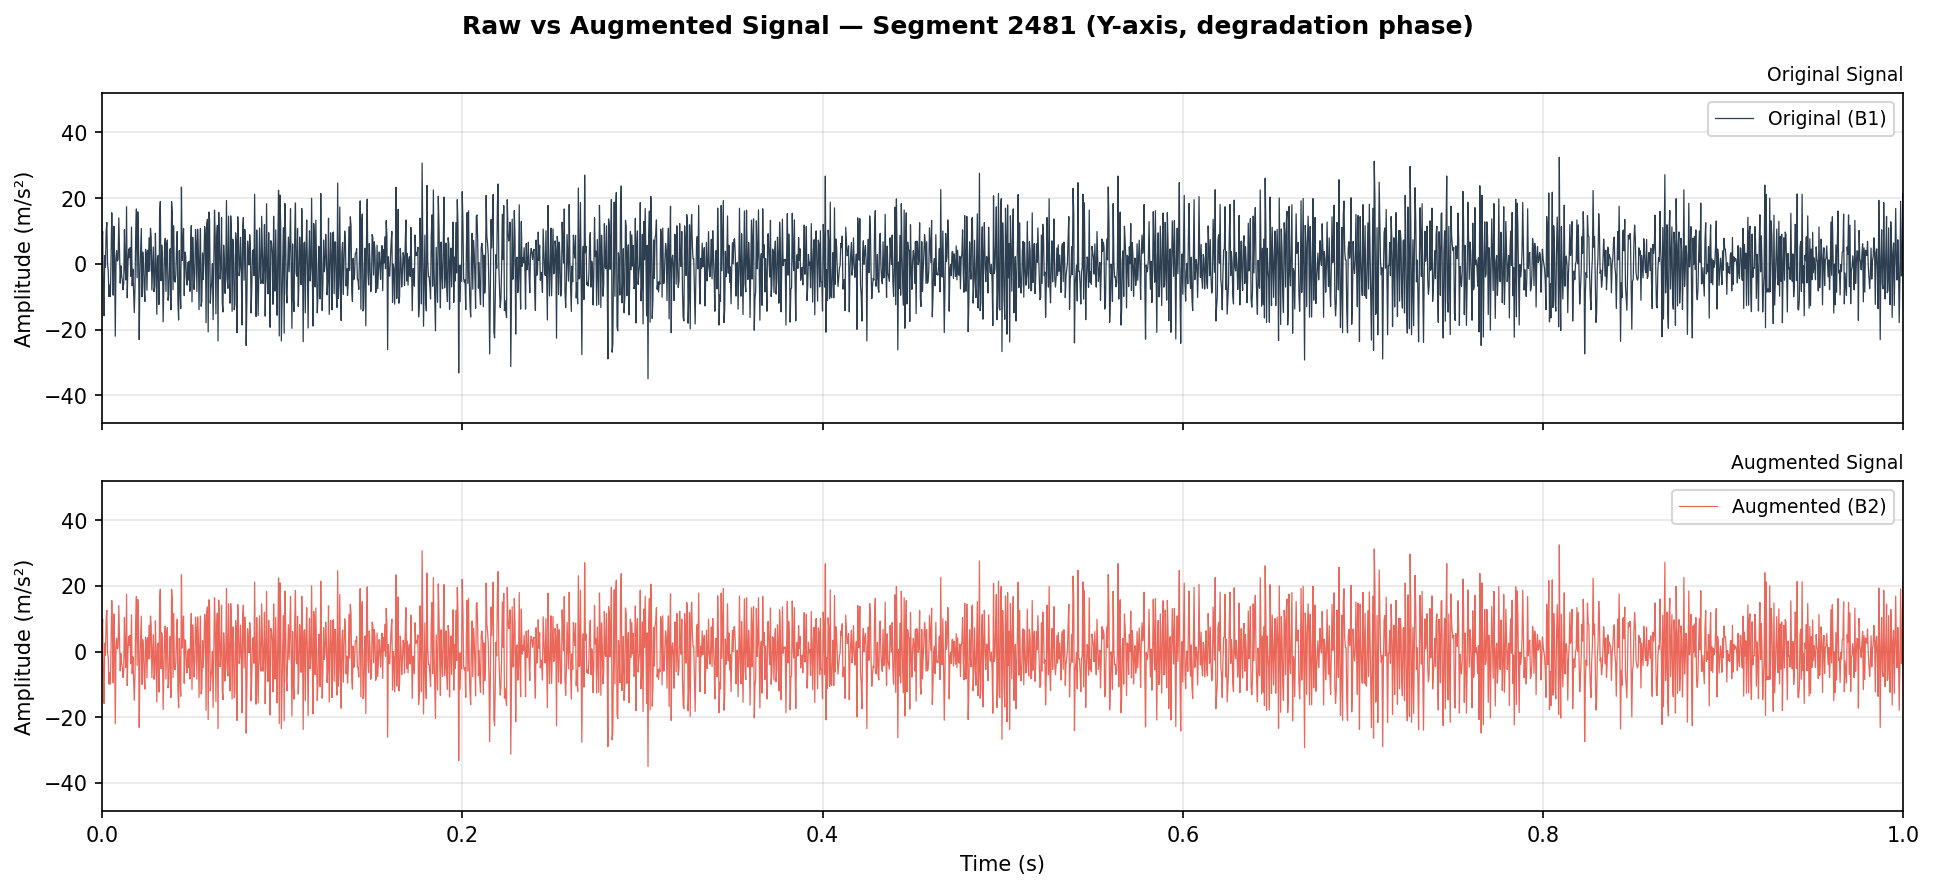

In [16]:
# Read a single degradation-phase segment from raw parquet for comparison
sample_seg_idx = TCP_B1 + 100
offset         = sample_seg_idx * SAMPLES_PER_SEG
scanner        = dataset.scanner(columns=target_cols)
tbl            = scanner.to_table()
raw_seg_y      = tbl.slice(offset, SAMPLES_PER_SEG).to_pandas().iloc[:, 1].values.astype(np.float64)
aug_seg_y      = augment_segment(raw_seg_y.copy(), sample_seg_idx, TCP_B1)

t_seg = np.arange(SAMPLES_PER_SEG) / SAMPLING_RATE

fig, axes_sig = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
fig.suptitle(f'Raw vs Augmented Signal — Segment {sample_seg_idx} (Y-axis, degradation phase)',
             fontweight='bold', fontsize=12)

axes_sig[0].plot(t_seg, raw_seg_y, color='#2C3E50', lw=0.6, label='Original (B1)')
axes_sig[0].set_ylabel('Amplitude (m/s²)')
axes_sig[0].legend()
axes_sig[0].set_title('Original Signal', loc='right', fontsize=9)

axes_sig[1].plot(t_seg, aug_seg_y, color='#E74C3C', lw=0.6, label='Augmented (B2)', alpha=0.85)
axes_sig[1].set_ylabel('Amplitude (m/s²)')
axes_sig[1].set_xlabel('Time (s)')
axes_sig[1].legend()
axes_sig[1].set_title('Augmented Signal', loc='right', fontsize=9)

for a in axes_sig:
    a.set_xlim(0, 1.0)  # show first 1 second for readability

plt.tight_layout()
plt.savefig('plot5_signal_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

---

## 13. Save Output

In [17]:
os.makedirs(os.path.dirname(OUTPUT_PARQUET), exist_ok=True)

df_b2.to_parquet(OUTPUT_PARQUET, engine='pyarrow', index=False)
print(f"Saved unscaled: {OUTPUT_PARQUET} | Shape: {df_b2.shape}")

Saved unscaled: D:\ProyekDosen\Riset Bearing ShaftMissalignment + XAI\bearing_2\processed_bearing2_synthetic_100db.parquet | Shape: (6480, 64)


---

## 14. Summary Report

In [18]:
print("=" * 60)
print("PREPROCESSING SUMMARY — BEARING-2 (SYNTHETIC)")
print("=" * 60)
print(f"Source signal          : Bearing-1 raw parquet")
print(f"Augmentation strategy  : Gaussian noise + amplitude scaling")
print(f"  SNR healthy phase    : {SNR_HEALTHY_DB} dB")
print(f"  SNR degrade phase    : {SNR_DEGRADE_DB} dB")
print(f"  Scale healthy        : {SCALE_HEALTHY}")
print(f"  Scale degrade        : {SCALE_DEGRADE}")
print()
print(f"Segments extracted     : {seg_count}")
print()
print(f"Bearing-1 TCP          : {TCP_B1} min  ({TCP_B1/60:.2f} h)")
print(f"Perturbation           : {perturb:+d} min")
print(f"Bearing-2 TCP          : {TCP_B2} min  ({TCP_B2/60:.2f} h)")
print(f"Degradation type       : {DEGRADATION_TYPE}")
print(f"BHI range              : [{bhi_b2.min():.4f}, {bhi_b2.max():.4f}]")
print()
print(f"Scaler fitted on       : Bearing-1 feature space")
print(f"Median feature corr    : {corr_series.median():.4f}")
print()
print(f"Output file            : {OUTPUT_PARQUET}")
print("=" * 60)

PREPROCESSING SUMMARY — BEARING-2 (SYNTHETIC)
Source signal          : Bearing-1 raw parquet
Augmentation strategy  : Gaussian noise + amplitude scaling
  SNR healthy phase    : 100 dB
  SNR degrade phase    : 95 dB
  Scale healthy        : (1.0, 1.0)
  Scale degrade        : (1.0, 1.0)

Segments extracted     : 6480

Bearing-1 TCP          : 2381 min  (39.68 h)
Perturbation           : -45 min
Bearing-2 TCP          : 2336 min  (38.93 h)
Degradation type       : linear
BHI range              : [0.0000, 1.0000]

Scaler fitted on       : Bearing-1 feature space
Median feature corr    : 1.0000

Output file            : D:\ProyekDosen\Riset Bearing ShaftMissalignment + XAI\bearing_2\processed_bearing2_synthetic_100db.parquet
